In [21]:
import tensorflow as tf
import numpy as np
import random
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score
)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger
)

In [22]:
SEED = 29
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [23]:

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"GPU memory growth setting skipped: {e}")

In [24]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [25]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

In [26]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 100

LEARNING_RATE = 0.0001

DATASET_PATH = "../Mendeley_Dataset"

RESULTS_DIR = "results_1"

os.makedirs(RESULTS_DIR, exist_ok=True)

In [27]:
# train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(

#     rescale=1./255,

#     rotation_range=40,

#     zoom_range=[0, 0.3],

#     horizontal_flip=True,

#     vertical_flip=True,

#     validation_split=0.2
# )

# val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(

#     rescale=1./255,

#     validation_split=0.2
# )

In [28]:
# train_generator = train_datagen.flow_from_directory(

#     DATASET_PATH,

#     target_size=IMAGE_SIZE,

#     batch_size=BATCH_SIZE,

#     class_mode='categorical',

#     subset='training',

#     shuffle=True,

#     seed=SEED
# )

In [29]:
# val_generator = val_datagen.flow_from_directory(

#     DATASET_PATH,

#     target_size=IMAGE_SIZE,

#     batch_size=BATCH_SIZE,

#     class_mode='categorical',

#     subset='validation',

#     shuffle=False,

#     seed=SEED
# )

# CLASS_NAMES = list(train_generator.class_indices.keys())

# NUM_CLASSES = len(CLASS_NAMES)

# print("\nClasses:")
# print(CLASS_NAMES)

In [30]:
# print(train_generator.class_indices)

# from collections import Counter

# print("Train distribution:")
# print(Counter(train_generator.classes))

# print("Validation distribution:")
# print(Counter(val_generator.classes))

In [31]:
import os
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import preprocess_input

# Collect image paths and labels
DATASET_PATH = Path(DATASET_PATH)

image_paths = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    class_dir = DATASET_PATH / class_name

    if class_dir.is_dir():
        for img in class_dir.iterdir():
            image_paths.append(str(img))
            labels.append(class_name)

# Stratified split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED,
    shuffle=True
)

# DataFrames
train_df = pd.DataFrame({
    'filename': train_paths,
    'class': train_labels
})

val_df = pd.DataFrame({
    'filename': val_paths,
    'class': val_labels
})

# SAME augmentation as your original code
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generators
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)

Found 2460 validated image filenames belonging to 7 classes.
Found 616 validated image filenames belonging to 7 classes.
Classes: ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
Train samples: 2460
Validation samples: 616


In [32]:
base_model = ResNet50(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3),

    pooling='avg'
)

In [33]:
# base_model.trainable = False

In [34]:
# for layer in base_model.layers[:-40]:
#     layer.trainable = False

# for layer in base_model.layers[-40:]:
#     layer.trainable = True

In [35]:
x = base_model.output

outputs = Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [36]:
optimizer = Adam(
    learning_rate=LEARNING_RATE
)

In [37]:
model.compile(

    optimizer=optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,602,055 (90.03 MB)

 Trainable params: 23,548,935 (89.83 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [38]:
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    verbose=1
)

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=15,

    min_delta=0.001,

    restore_best_weights=True,

    verbose=1
)

checkpoint = ModelCheckpoint(

    filepath=os.path.join(
        RESULTS_DIR,
        "best.keras"
    ),

    monitor='val_loss',

    save_best_only=True,

    verbose=1
)

csv_logger = CSVLogger(

    os.path.join(
        RESULTS_DIR,
        "training_log.csv"
    )
)

In [39]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [40]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=EPOCHS,

    callbacks=[
        reduce_lr,
        early_stop,
        checkpoint,
        csv_logger
    ]
)

Epoch 1/100


I0000 00:00:1779742130.881555   21444 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_112077__.614
I0000 00:00:1779742141.903286   21444 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_convert_reduce_fusion_36', 16 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_convert_reduce_fusion_27', 16 bytes spill stores, 8 bytes spill loads



71/77 ━━━━━━━━━━━━━━━━━━━━ 2s 439ms/step - accuracy: 0.4822 - loss: 1.4070

I0000 00:00:1779742177.577713   21442 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_112077__.614
I0000 00:00:1779742188.632121   21442 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_convert_reduce_fusion_36', 16 bytes spill stores, 8 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_convert_reduce_fusion_27', 16 bytes spill stores, 8 bytes spill loads



77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.4948 - loss: 1.3743
Epoch 1: val_loss improved from None to 0.88639, saving model to results_1/best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 94s 810ms/step - accuracy: 0.6455 - loss: 0.9796 - val_accuracy: 0.7808 - val_loss: 0.8864 - learning_rate: 1.0000e-04
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8198 - loss: 0.4972
Epoch 2: val_loss improved from 0.88639 to 0.66262, saving model to results_1/best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 43s 553ms/step - accuracy: 0.8215 - loss: 0.5021 - val_accuracy: 0.7727 - val_loss: 0.6626 - learning_rate: 1.0000e-04
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.8664 - loss: 0.3600
Epoch 3: val_loss did not improve from 0.66262
77/77 ━━━━━━━━━━━━━━━━━━━━ 40s 520ms/step - accuracy: 0.8687 - loss: 0.3695 - val_accuracy: 0.7841 - val_loss: 0.7143 - learning_rate: 1.0000e-04
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8925 - loss: 0.3036
Epoc

In [41]:
model.save(
    os.path.join(
        RESULTS_DIR,
        "final.keras"
    )
)

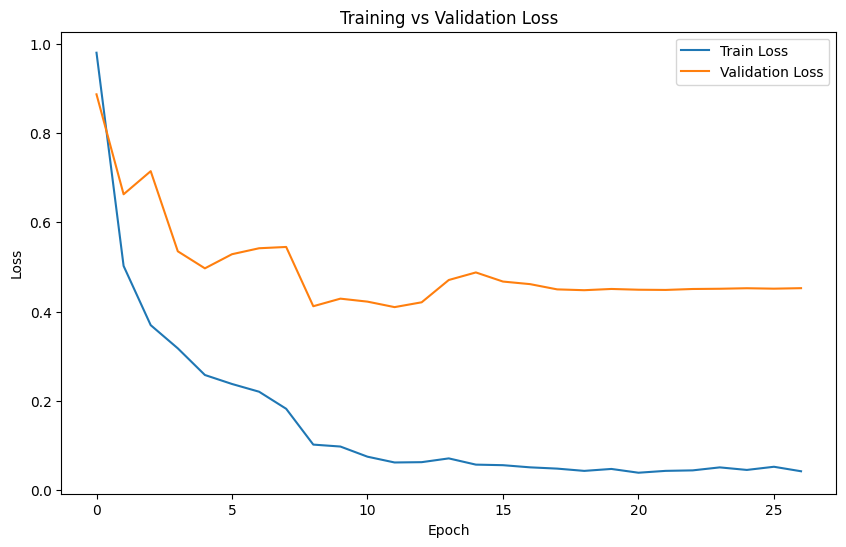

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "loss_curve.png"
    )
)


In [43]:
plt.close()

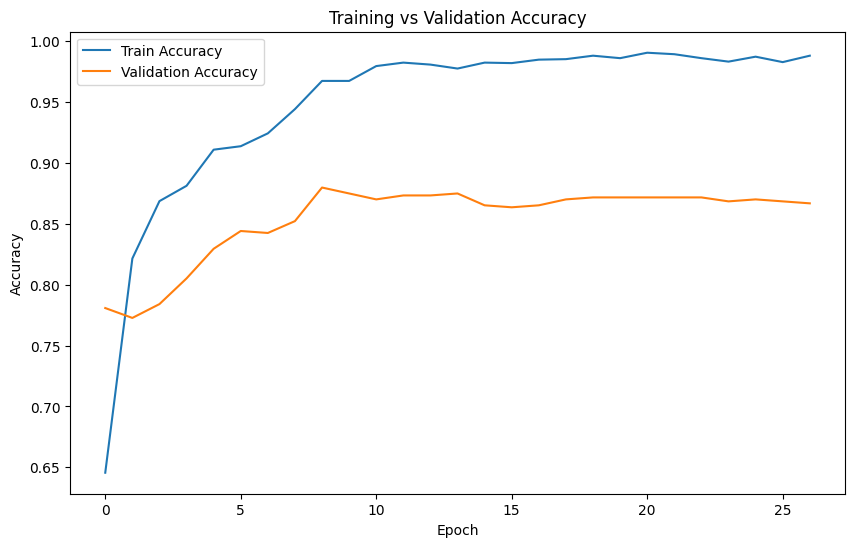

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "accuracy_curve.png"
    )
)


In [45]:

plt.close()

In [46]:
print("\nEvaluating Model...\n")

val_generator.reset()

predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = val_generator.classes


Evaluating Model...



E0000 00:00:1779743256.252900   21142 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 418ms/step


In [47]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

In [48]:
print("=" * 50)

print(f"Accuracy           : {accuracy*100:.2f}%")

print(f"Precision          : {precision*100:.2f}%")

print(f"Recall             : {recall*100:.2f}%")

print(f"F1 Score           : {f1*100:.2f}%")

print(f"MCC                : {mcc:.4f}")

print(f"Balanced Accuracy  : {balanced_acc*100:.2f}%")

print("=" * 50)


Accuracy           : 87.34%
Precision          : 88.14%
Recall             : 87.34%
F1 Score           : 87.52%
MCC                : 0.8465
Balanced Accuracy  : 86.76%


In [49]:
metrics = {

    "accuracy": float(accuracy),

    "precision": float(precision),

    "recall": float(recall),

    "f1_score": float(f1),

    "mcc": float(mcc),

    "balanced_accuracy": float(balanced_acc)
}

with open(
    os.path.join(
        RESULTS_DIR,
        "metrics.json"
    ),
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

In [50]:
report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES
)

print("\nClassification Report:\n")

print(report)

with open(
    os.path.join(
        RESULTS_DIR,
        "classification_report.txt"
    ),
    "w"
) as f:

    f.write(report)


Classification Report:

              precision    recall  f1-score   support

    Bacteria       0.98      0.96      0.97       114
       Fungi       0.88      0.86      0.87       150
     Healthy       0.69      0.93      0.79        40
    Nematode       0.92      0.79      0.85        14
        Pest       0.77      0.84      0.80       122
 Phytopthora       0.92      0.87      0.90        69
       Virus       0.94      0.83      0.88       107

    accuracy                           0.87       616
   macro avg       0.87      0.87      0.87       616
weighted avg       0.88      0.87      0.88       616



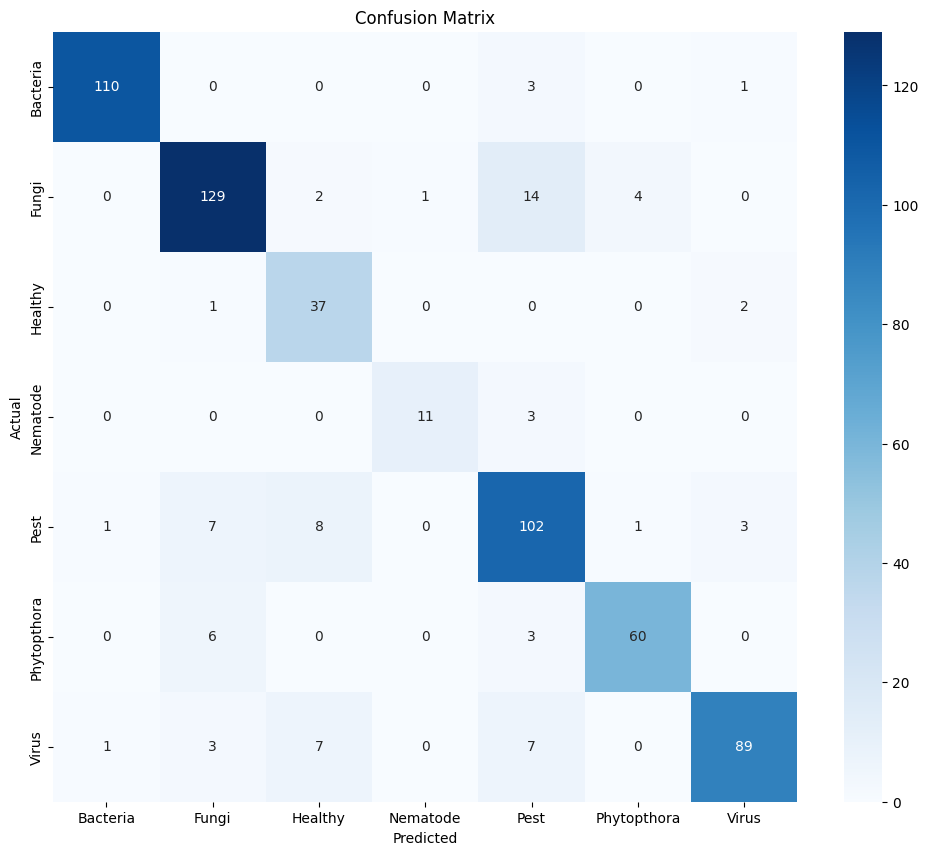

In [51]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "confusion_matrix.png"
    )
)


In [52]:

plt.close()

In [53]:
history_dict = history.history

with open(
    os.path.join(
        RESULTS_DIR,
        "history.json"
    ),
    "w"
) as f:

    json.dump(
        history_dict,
        f,
        indent=4
    )

print("\nEverything saved in /results directory")

print("\nSaved Files:")

for file in os.listdir(RESULTS_DIR):
    print(" -", file)


Everything saved in /results directory

Saved Files:
 - final.keras
 - loss_curve.png
 - metrics.json
 - history.json
 - accuracy_curve.png
 - training_log.csv
 - confusion_matrix.png
 - best.keras
 - classification_report.txt


In [54]:
train_set = set(train_paths)
val_set = set(val_paths)

print("Overlap:", len(train_set & val_set))

Overlap: 0


In [55]:
print(train_df['class'].value_counts())
print(val_df['class'].value_counts())

class
Fungi          598
Pest           489
Bacteria       455
Virus          425
Phytopthora    278
Healthy        161
Nematode        54
Name: count, dtype: int64
class
Fungi          150
Pest           122
Bacteria       114
Virus          107
Phytopthora     69
Healthy         40
Nematode        14
Name: count, dtype: int64
